In [1]:
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler

import joblib


In [3]:
import pandas as pd
df = pd.read_excel(
    "MCRFPUS1m.xls"
)
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,Workbook Contents,NaN,NaN,NaN,NaN
1,NaN,U.S. Field Production of Crude Oil (Thousand B...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Click worksheet name or tab at bottom for data,NaN,NaN,NaN,NaN
4,NaN,Worksheet Name,Description,# Of Series,Frequency,Latest Data for


In [4]:
df = pd.read_excel(
    "MCRFPUS1m.xls",
    sheet_name="Data 1"
)

df.head()

,Back to Contents,Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)
0,Sourcekey,MCRFPUS1
1,Date,U.S. Field Production of Crude Oil (Thousand B...
2,1920-01-15 00:00:00,34008
3,1920-02-15 00:00:00,33193
4,1920-03-15 00:00:00,36171


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1277 entries, 0 to 1276
Data columns (total 2 columns):
 #   Column                                                         Non-Null Count  Dtype 
---  ------                                                         --------------  ----- 
 0   Back to Contents                                               1277 non-null   object
 1   Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)  1277 non-null   object
dtypes: object(2)
memory usage: 20.1+ KB


In [6]:
print(df.dtypes)

Back to Contents                                                 object
Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)    object
dtype: object


In [9]:
df.head(10)

,Date,Production
0,Sourcekey,MCRFPUS1
1,Date,U.S. Field Production of Crude Oil (Thousand B...
2,1920-01-15 00:00:00,34008
3,1920-02-15 00:00:00,33193
4,1920-03-15 00:00:00,36171
5,1920-04-15 00:00:00,34945
6,1920-05-15 00:00:00,36622
7,1920-06-15 00:00:00,36663
8,1920-07-15 00:00:00,37746
9,1920-08-15 00:00:00,38906


In [10]:
import pandas as pd

df = pd.read_excel(
    "MCRFPUS1m.xls",
    sheet_name="Data 1"
)

df.columns = ["Date", "Production"]

# Remove first two metadata rows
df = df.iloc[2:]

# Remove the row containing the word "Date"
df = df[df["Date"] != "Date"]

# Convert data types
df["Date"] = pd.to_datetime(df["Date"])
df["Production"] = pd.to_numeric(df["Production"])

# Reset index
df.reset_index(drop=True, inplace=True)

df.head()

,Date,Production
0,1920-01-15,34008
1,1920-02-15,33193
2,1920-03-15,36171
3,1920-04-15,34945
4,1920-05-15,36622


In [11]:
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [12]:
print(df.dtypes)

Date          datetime64[us]
Production             int64
dtype: object


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1275 non-null   datetime64[us]
 1   Production  1275 non-null   int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 20.1 KB


In [15]:
print(f"Shape: {df.shape}")

Shape: (1275, 2)


In [16]:
print(df["Date"].min())
print(df["Date"].max())

1920-01-15 00:00:00
2026-03-15 00:00:00


In [17]:
df.describe()

,Date,Production
count,1275,1275.000000
mean,1973-02-13 08:51:57.176470,199370.100392
min,1920-01-15 00:00:00,33193.000000
25%,1946-07-30 12:00:00,145468.500000
50%,1973-02-15 00:00:00,201763.000000
75%,1999-08-30 12:00:00,259583.500000
max,2026-03-15 00:00:00,429777.000000
std,NaN,86379.860990


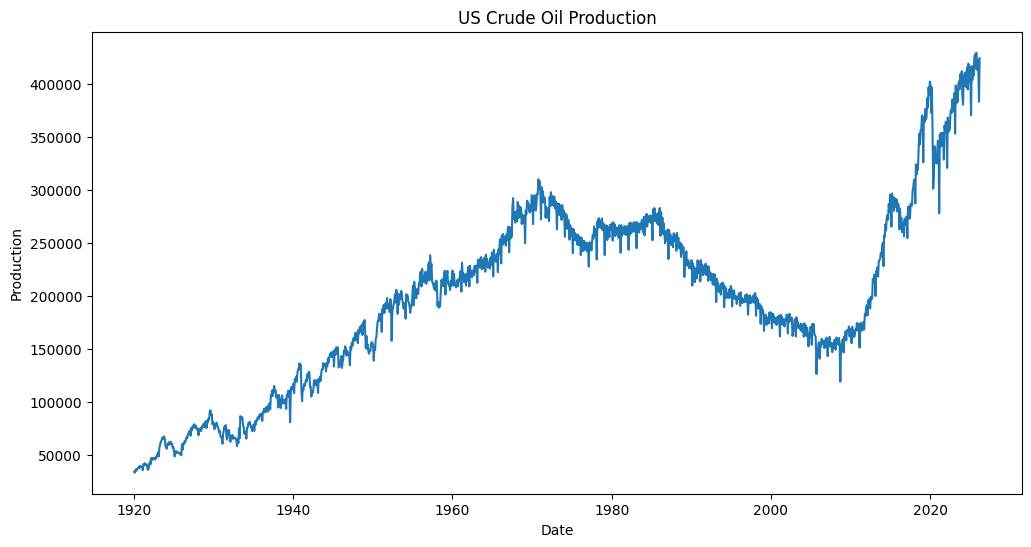

In [20]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Production"])
plt.xlabel("Date")
plt.ylabel("Production")
plt.title("US Crude Oil Production")
plt.show()

In [21]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

In [22]:
df.head()

,Date,Production,Month,Year
0,1920-01-15,34008,1,1920
1,1920-02-15,33193,2,1920
2,1920-03-15,36171,3,1920
3,1920-04-15,34945,4,1920
4,1920-05-15,36622,5,1920


In [23]:
monthly_avg = df.groupby("Month")["Production"].mean()
print(monthly_avg)

Month
1     202450.214953
2     186021.074766
3     205026.775701
4     196275.971698
5     201593.405660
6     195203.235849
7     201421.952830
8     202025.433962
9     195476.075472
10    203708.216981
11    198481.594340
12    204800.764151
Name: Production, dtype: float64


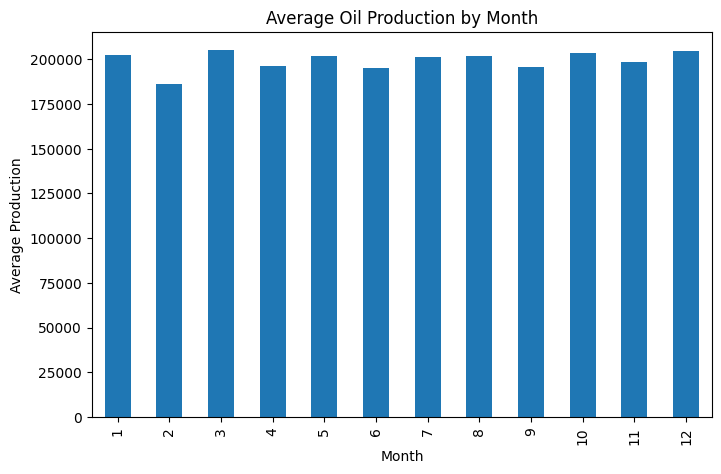

In [24]:
monthly_avg.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Oil Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.show()

In [25]:
df["lag_1"] = df["Production"].shift(1)
df[["Date", "Production", "lag_1"]].head(10)

,Date,Production,lag_1
0,1920-01-15,34008,NaN
1,1920-02-15,33193,34008.0
2,1920-03-15,36171,33193.0
3,1920-04-15,34945,36171.0
4,1920-05-15,36622,34945.0
5,1920-06-15,36663,36622.0
6,1920-07-15,37746,36663.0
7,1920-08-15,38906,37746.0
8,1920-09-15,37521,38906.0
9,1920-10-15,39584,37521.0


In [26]:
df["lag_3"] = df["Production"].shift(3)
df["lag_6"] = df["Production"].shift(6)
df["lag_12"] = df["Production"].shift(12)

In [27]:
df[
    ["Date",
     "Production",
     "lag_1",
     "lag_3",
     "lag_6",
     "lag_12"]
].head(15)

,Date,Production,lag_1,lag_3,lag_6,lag_12
0,1920-01-15,34008,NaN,NaN,NaN,NaN
1,1920-02-15,33193,34008.0,NaN,NaN,NaN
2,1920-03-15,36171,33193.0,NaN,NaN,NaN
3,1920-04-15,34945,36171.0,34008.0,NaN,NaN
4,1920-05-15,36622,34945.0,33193.0,NaN,NaN
5,1920-06-15,36663,36622.0,36171.0,NaN,NaN
6,1920-07-15,37746,36663.0,34945.0,34008.0,NaN
7,1920-08-15,38906,37746.0,36622.0,33193.0,NaN
8,1920-09-15,37521,38906.0,36663.0,36171.0,NaN
9,1920-10-15,39584,37521.0,37746.0,34945.0,NaN


In [28]:
df["rolling_mean_3"] = df["Production"].rolling(3).mean()

df[
    ["Date",
     "Production",
     "rolling_mean_3"]
].head(10)

,Date,Production,rolling_mean_3
0,1920-01-15,34008,NaN
1,1920-02-15,33193,NaN
2,1920-03-15,36171,34457.333333
3,1920-04-15,34945,34769.666667
4,1920-05-15,36622,35912.666667
5,1920-06-15,36663,36076.666667
6,1920-07-15,37746,37010.333333
7,1920-08-15,38906,37771.666667
8,1920-09-15,37521,38057.666667
9,1920-10-15,39584,38670.333333


In [29]:
df["rolling_mean_6"] = df["Production"].rolling(6).mean()

df["rolling_mean_12"] = df["Production"].rolling(12).mean()

In [30]:
df.isnull().sum

<bound method DataFrame.sum of        Date  Production  Month   Year  lag_1  lag_3  lag_6  lag_12  \
0     False       False  False  False   True   True   True    True   
1     False       False  False  False  False   True   True    True   
2     False       False  False  False  False   True   True    True   
3     False       False  False  False  False  False   True    True   
4     False       False  False  False  False  False   True    True   
...     ...         ...    ...    ...    ...    ...    ...     ...   
1270  False       False  False  False  False  False  False   False   
1271  False       False  False  False  False  False  False   False   
1272  False       False  False  False  False  False  False   False   
1273  False       False  False  False  False  False  False   False   
1274  False       False  False  False  False  False  False   False   

      rolling_mean_3  rolling_mean_6  rolling_mean_12  
0               True            True             True  
1               

In [31]:
df.isnull().sum()

Date                0
Production          0
Month               0
Year                0
lag_1               1
lag_3               3
lag_6               6
lag_12             12
rolling_mean_3      2
rolling_mean_6      5
rolling_mean_12    11
dtype: int64

In [32]:
df.dropna()

,Date,Production,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
12,1921-01-15,38138,1,1921,38961.0,39584.0,37746.0,34008.0,38569.333333,38619.833333,37254.916667
13,1921-02-15,35524,2,1921,38138.0,38609.0,38906.0,33193.0,37541.000000,38056.166667,37449.166667
14,1921-03-15,41105,3,1921,35524.0,38961.0,37521.0,36171.0,38255.666667,38653.500000,37860.333333
15,1921-04-15,40233,4,1921,41105.0,38138.0,39584.0,34945.0,38954.000000,38761.666667,38301.000000
16,1921-05-15,42189,5,1921,40233.0,35524.0,38609.0,36622.0,41175.666667,39358.333333,38764.916667
...,...,...,...,...,...,...,...,...,...,...,...
1270,2025-11-15,413677,11,2025,429777.0,428114.0,416844.0,401875.0,419433.000000,419942.333333,412676.833333
1271,2025-12-15,423356,12,2025,413677.0,414845.0,408315.0,416555.0,422270.000000,422449.166667,413243.583333
1272,2026-01-15,412456,1,2026,423356.0,429777.0,424926.0,407352.0,416496.333333,420370.833333,413668.916667
1273,2026-02-15,383507,2,2026,412456.0,413677.0,428114.0,370707.0,406439.666667,412936.333333,414735.583333


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1275 non-null   datetime64[us]
 1   Production       1275 non-null   int64         
 2   Month            1275 non-null   int32         
 3   Year             1275 non-null   int32         
 4   lag_1            1274 non-null   float64       
 5   lag_3            1272 non-null   float64       
 6   lag_6            1269 non-null   float64       
 7   lag_12           1263 non-null   float64       
 8   rolling_mean_3   1273 non-null   float64       
 9   rolling_mean_6   1270 non-null   float64       
 10  rolling_mean_12  1264 non-null   float64       
dtypes: datetime64[us](1), float64(7), int32(2), int64(1)
memory usage: 99.7 KB


In [34]:
df.head()

,Date,Production,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
0,1920-01-15,34008,1,1920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1920-02-15,33193,2,1920,34008.0,NaN,NaN,NaN,NaN,NaN,NaN
2,1920-03-15,36171,3,1920,33193.0,NaN,NaN,NaN,34457.333333,NaN,NaN
3,1920-04-15,34945,4,1920,36171.0,34008.0,NaN,NaN,34769.666667,NaN,NaN
4,1920-05-15,36622,5,1920,34945.0,33193.0,NaN,NaN,35912.666667,NaN,NaN


In [36]:
df = df[df["Date"] >= "1980-01-01"].copy()
df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             555 non-null    datetime64[us]
 1   Production       555 non-null    int64         
 2   Month            555 non-null    int32         
 3   Year             555 non-null    int32         
 4   lag_1            555 non-null    float64       
 5   lag_3            555 non-null    float64       
 6   lag_6            555 non-null    float64       
 7   lag_12           555 non-null    float64       
 8   rolling_mean_3   555 non-null    float64       
 9   rolling_mean_6   555 non-null    float64       
 10  rolling_mean_12  555 non-null    float64       
dtypes: datetime64[us](1), float64(7), int32(2), int64(1)
memory usage: 43.5 KB


In [37]:
print(df["Date"].min())
print(df["Date"].max())
print(df.shape)

1980-01-15 00:00:00
2026-03-15 00:00:00
(555, 11)


In [38]:
features = [
    "Month",
    "Year",
    "lag_1",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_12"
]

X = df[features]

y = df["Production"]

In [39]:
print(X.shape)
print(y.shape)
X.head()

(555, 9)
(555,)


,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
0,1,1980,267050.0,267256.0,259278.0,262716.0,266269.333333,264456.333333,260627.833333
1,2,1980,268940.0,262818.0,264981.0,238710.0,262807.000000,262364.666667,261771.250000
2,3,1980,252431.0,267050.0,255693.0,266635.0,263673.666667,264690.833333,262022.500000
3,4,1980,269650.0,268940.0,267256.0,256593.0,260874.000000,263571.666667,262351.500000
4,5,1980,260541.0,252431.0,262818.0,266631.0,265958.333333,264382.666667,262439.250000


In [40]:
corr = df[
    [
        "Production",
        "lag_1",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_mean_3",
        "rolling_mean_6",
        "rolling_mean_12"
    ]
].corr()

corr

,Production,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
Production,1.000000,0.983137,0.983083,0.971755,0.966963,0.994955,0.992621,0.986696
lag_1,0.983137,1.000000,0.985616,0.981280,0.956386,0.994094,0.992812,0.988671
lag_3,0.983083,0.985616,1.000000,0.982804,0.967375,0.989263,0.993714,0.991606
lag_6,0.971755,0.981280,0.982804,1.000000,0.970358,0.983076,0.987634,0.992661
lag_12,0.966963,0.956386,0.967375,0.970358,1.000000,0.967851,0.973248,0.982567
rolling_mean_3,0.994955,0.994094,0.989263,0.983076,0.967851,1.000000,0.998392,0.993913
rolling_mean_6,0.992621,0.992812,0.993714,0.987634,0.973248,0.998392,1.000000,0.997378
rolling_mean_12,0.986696,0.988671,0.991606,0.992661,0.982567,0.993913,0.997378,1.000000


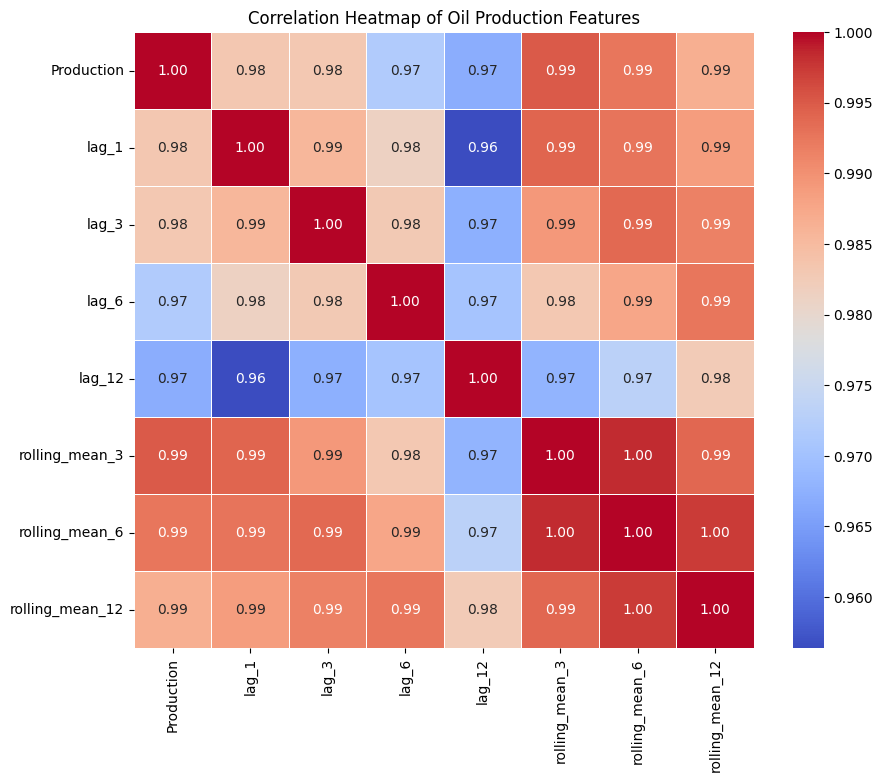

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[
    [
        "Production",
        "lag_1",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_mean_3",
        "rolling_mean_6",
        "rolling_mean_12"
    ]
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,      # show numbers
    fmt=".2f",       # 2 decimal places
    cmap="coolwarm", # color scheme
    linewidths=0.5
)

plt.title("Correlation Heatmap of Oil Production Features")
plt.show()

In [44]:
tscv = TimeSeriesSplit(n_splits=5)

In [47]:
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    
    print(f"\nSplit {i+1}")
    
    print("Train Size:", len(train_idx))
    print("Test Size :", len(test_idx))
    
    print("Train End Index:", train_idx[-1])
    print("Test Start Index:", test_idx[0])


Split 1
Train Size: 95
Test Size : 92
Train End Index: 94
Test Start Index: 95

Split 2
Train Size: 187
Test Size : 92
Train End Index: 186
Test Start Index: 187

Split 3
Train Size: 279
Test Size : 92
Train End Index: 278
Test Start Index: 279

Split 4
Train Size: 371
Test Size : 92
Train End Index: 370
Test Start Index: 371

Split 5
Train Size: 463
Test Size : 92
Train End Index: 462
Test Start Index: 463


In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(555, 9)


In [49]:
print(X_scaled[:5])

[[-1.58301992 -1.69470018  0.33373883  0.34585158  0.25251476  0.33552311
   0.32429819  0.30757222  0.27165035]
 [-1.29391954 -1.69470018  0.35949051  0.28489312  0.33217252 -0.01116037
   0.27690427  0.27868973  0.2877435 ]
 [-1.00481916 -1.69470018  0.13455164  0.34302205  0.20244058  0.39211948
   0.28876758  0.31081028  0.29127975]
 [-0.71571878 -1.69470018  0.36916442  0.36898228  0.36394903  0.24709759
   0.25044452  0.29535642  0.29591029]
 [-0.4266184  -1.69470018  0.24505223  0.14222174  0.3019604   0.39206171
   0.32004109  0.306555    0.29714534]]


In [50]:
mae_scores = []
mse_scores = []
r2_scores = []

In [51]:
for train_idx, test_idx in tscv.split(X)
print("Train: ", len(train_idx))
print("Test: ", len(test_idx))
break

SyntaxError: expected ':' (4257494643.py, line 1)

In [52]:
for train_idx, test_idx in tscv.split(X):
print("Train: ", len(train_idx))
print("Test: ", len(test_idx))
break

IndentationError: expected an indented block after 'for' statement on line 1 (3630036567.py, line 2)

In [53]:
for train_idx, test_idx in tscv.split(X):
    
    print("TRAIN:", len(train_idx))
    print("TEST :", len(test_idx))
    
    break

TRAIN: 95
TEST : 92


In [54]:
for train_idx, test_idx in tscv.split(X):
    
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    break

In [55]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(95, 9)
(92, 9)
(95,)
(92,)


In [56]:
scaler = StandardScaler()

In [57]:
X_train_scaled = scaler.fit_transform(X_train)

In [58]:
X_test_scaled = scaler.transform(X_test)

In [59]:
model = linearRegression()

NameError: name 'linearRegression' is not defined

In [60]:
model = LinearRegression()

In [61]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
y_pred = model.predict(
    x_test_scaled)

NameError: name 'x_test_scaled' is not defined

In [63]:
y_pred = model.predict(
    X_test_scaled
)

In [64]:
y_pred = model.predict(
    X_test_scaled
)

In [65]:
print(y_pred[:10])

[255774.34797302 258806.60967903 240743.29108287 258713.92163715
 247385.32051199 254638.47127688 245328.17621719 249070.57165926
 247272.47199436 237248.21345759]


In [67]:
mae = mean_absolute_error(
    y_test,
    y_pred
)
print("MAE: ", mae)

MAE:  4114.158547226025


In [70]:
rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

print("RMSE:", rmse)

RMSE: 4803.188442524225


In [71]:
r2 = r2_score (

_IncompleteInputError: incomplete input (3611042332.py, line 1)

In [72]:
r2 = r2_score (
    y_test,
    y_pred
)
print("R2_Score: ", r2)

R2_Score:  0.9135188742394382


In [73]:
import pandas as pd 
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "predicted": y_pred
})
comparison.head(10)

,Actual,predicted
0,257844,255774.347973
1,255743,258806.609679
2,242848,240743.291083
3,259587,258713.921637
4,248629,247385.320512
5,255089,254638.471277
6,245102,245328.176217
7,249229,249070.571659
8,250459,247272.471994
9,236847,237248.213458


In [74]:
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )

    mae_scores.append(mae)

    rmse_scores.append(rmse)

    r2_scores.append(r2)

NameError: name 'rmse_scores' is not defined

In [76]:
mae_scores = []
rmse_scores = []
r2_scores = []

In [77]:
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    r2 = r2_score(y_test, y_pred)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

In [78]:
print("MAE Scores:")
print(mae_scores)

print("\nRMSE Scores:")
print(rmse_scores)

print("\nR2 Scores:")
print(r2_scores)

MAE Scores:
[4114.158547226025, 2185.15021173318, 3830.065850852116, 3763.3696390826885, 7550.510978302469]

RMSE Scores:
[4803.188442524225, 2886.6054035118973, 5446.843558432736, 4762.419376550173, 11270.151255015531]

R2 Scores:
[0.9135188742394382, 0.9307325842421098, 0.6993888031795943, 0.9894750182935159, 0.8713838978860072]


In [79]:
print("Average MAE :", sum(mae_scores) / len(mae_scores))
print("Average RMSE :", sum(rmse_scores) / len(rmse_scores))
print("Average R2 :", sum(r2_scores) / len(r2_scores))

Average MAE : 4288.651045439296
Average RMSE : 5833.841607206913
Average R2 : 0.880899835568133


In [80]:
from sklearn.ensemble import RandomForestRegressor

In [81]:
rf_mae_scores = []
rf_rmse_scores = []
rf_r2_scores = []

In [82]:
for train_idx, test_idx in tscv.split(X):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = RandomForestRressor(
    n_estimates = 100, 
    random_state = 42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
     mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )
rf_mae_scores.append(mae)
rf_rmse_scores.append(rmse)
rf_r2_scores.append(r2_scores)

IndentationError: unexpected indent (3079007169.py, line 15)

In [83]:
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )

    rf_mae_scores.append(mae)
    rf_rmse_scores.append(rmse)
    rf_r2_scores.append(r2)

In [84]:
print("RF MAE:", rf_mae_scores)

print("RF RMSE:", rf_rmse_scores)

print("RF R2:", rf_r2_scores)

RF MAE: [27314.66347826087, 13081.462500000003, 7770.431956521737, 15373.928695652176, 48750.07934782608]
RF RMSE: [31159.800643224593, 15935.103108972322, 10720.224519458638, 19297.579239118197, 55643.61402692934]
RF R2: [-2.6395812929549494, -1.1108817278312486, -0.16445607557952235, 0.8271888571284018, -2.1352091150955324]


In [85]:
print(
    "RF Average MAE:",
    sum(rf_mae_scores) / len(rf_mae_scores)
)

print(
    "RF Average RMSE:",
    sum(rf_rmse_scores) / len(rf_rmse_scores)
)

print(
    "RF Average R2:",
    sum(rf_r2_scores) / len(rf_r2_scores)
)

RF Average MAE: 22458.113195652175
RF Average RMSE: 26551.26430754062
RF Average R2: -1.0445878708665703


In [86]:
print(X.shape)

(555, 9)


In [87]:
print(X.shape)
print(df.shape)

(555, 9)
(555, 11)


In [88]:
import xgboost as xgb

In [89]:
xgb_mae_scores = []
xgb_rmse_scores = []
xgb_r2_scores = []

In [90]:
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )

    xgb_mae_scores.append(mae)
    xgb_rmse_scores.append(rmse)
    xgb_r2_scores.append(r2)

In [91]:
print("XGB MAE:", xgb_mae_scores)

print("XGB RMSE:", xgb_rmse_scores)

print("XGB R2:", xgb_r2_scores)

XGB MAE: [27754.91796875, 15098.9833984375, 6716.27783203125, 16830.203125, 49780.87109375]
XGB RMSE: [31467.396714695038, 18178.180326974423, 9382.77954552914, 21394.017855466045, 56368.99005659051]
XGB R2: [-2.7117927074432373, -1.746976613998413, 0.10797220468521118, 0.7876018285751343, -2.2174837589263916]


In [92]:
print(
    "XGB Average MAE:",
    sum(xgb_mae_scores) / len(xgb_mae_scores)
)

print(
    "XGB Average RMSE:",
    sum(xgb_rmse_scores) / len(xgb_rmse_scores)
)

print(
    "XGB Average R2:",
    sum(xgb_r2_scores) / len(xgb_r2_scores)
)

XGB Average MAE: 23236.25068359375
XGB Average RMSE: 27358.272899851036
XGB Average R2: -1.1561358094215393


In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Feature Importance (Absolute Coefficients)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

AttributeError: Coefficients are not defined for Booster type None

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Feature Importance (Absolute Coefficients)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

AttributeError: Coefficients are not defined for Booster type None

In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

lr_model = LinearRegression()

lr_model.fit(X_scaled, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [96]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient,Abs_Coefficient
6,rolling_mean_3,106390.663041,106390.663041
8,rolling_mean_12,-44079.257380,44079.257380
2,lag_1,-27755.648304,27755.648304
7,rolling_mean_6,22250.012068,22250.012068
5,lag_12,14568.145505,14568.145505
3,lag_3,5427.896083,5427.896083
4,lag_6,-3502.405238,3502.405238
0,Month,539.910398,539.910398
1,Year,462.942621,462.942621


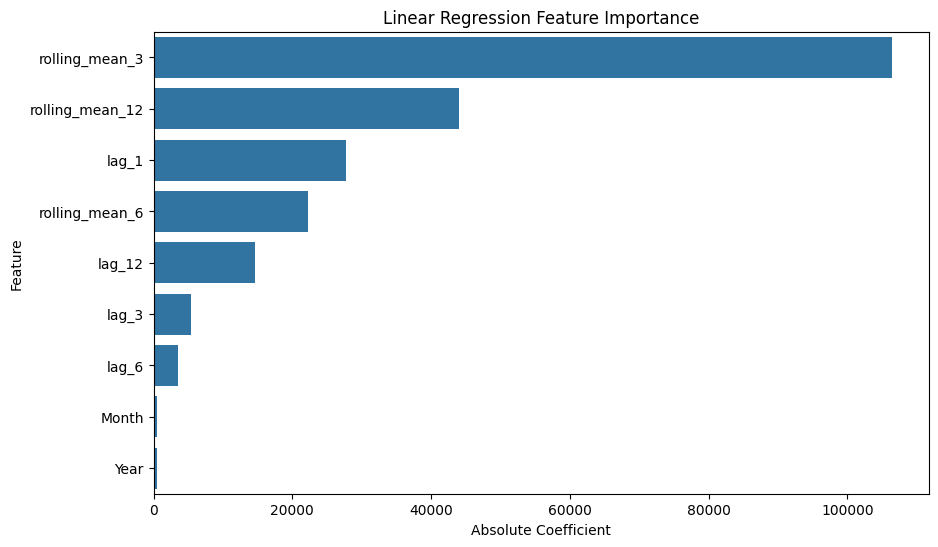

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.show()

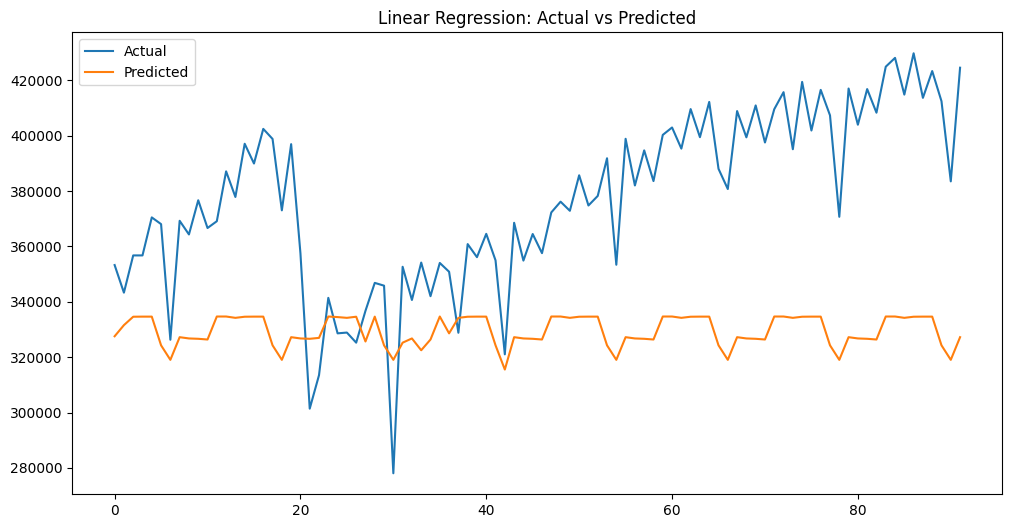

In [98]:
plt.figure(figsize=(12, 6))
plt.plot(
    y_test.values,
    label="Actual"
)
plt.plot(
    y_pred, 
    label="Predicted"
)
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()

In [99]:
print(len(y_test))
print(len(y_pred))

92
92


In [100]:
print(y_test[:5])
print(y_pred[:5])

463    353277
464    343308
465    356755
466    356757
467    370487
Name: Production, dtype: int64
[327550.16 331565.   334608.34 334644.   334644.  ]


In [101]:
comparison.head(10)

,Actual,predicted
0,257844,255774.347973
1,255743,258806.609679
2,242848,240743.291083
3,259587,258713.921637
4,248629,247385.320512
5,255089,254638.471277
6,245102,245328.176217
7,249229,249070.571659
8,250459,247272.471994
9,236847,237248.213458


In [102]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# First split only
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lr_model = LinearRegression()

    lr_model.fit(X_train_scaled, y_train)

    lr_pred = lr_model.predict(X_test_scaled)

    break

In [103]:

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_pred
})

comparison.head(10)

,Actual,Predicted
0,257844,255774.347973
1,255743,258806.609679
2,242848,240743.291083
3,259587,258713.921637
4,248629,247385.320512
5,255089,254638.471277
6,245102,245328.176217
7,249229,249070.571659
8,250459,247272.471994
9,236847,237248.213458


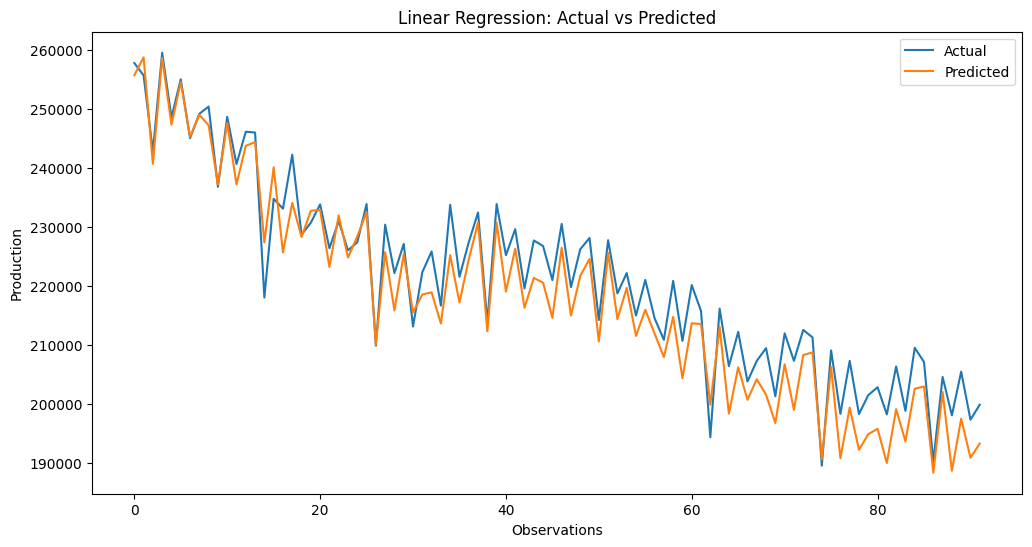

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    lr_pred,
    label="Predicted"
)

plt.title("Linear Regression: Actual vs Predicted")

plt.xlabel("Observations")
plt.ylabel("Production")

plt.legend()

plt.show()

In [105]:
residuals = y_test.values - lr_pred
print("Residual mean: ", residuals.mean())
print("Residuals std: ", residuals.std())

Residual mean:  3429.5526299493727
Residuals std:  3362.854140875819


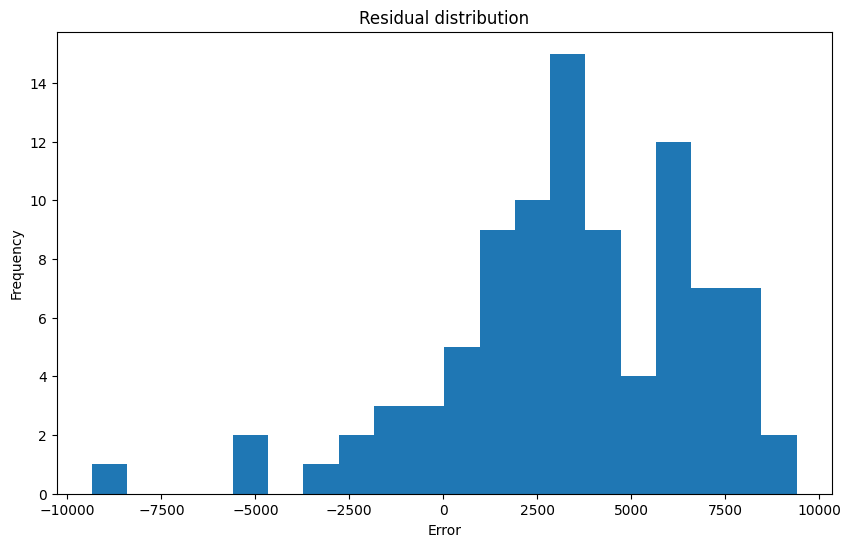

In [106]:
plt.figure(figsize=(10, 6))
plt.hist(
    residuals,
    bins = 20
)
plt.title("Residual distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [107]:
print("Residual Mean:", residuals.mean())
print("Residual Median:", residuals.mean())

Residual Mean: 3429.5526299493727
Residual Median: 3429.5526299493727


In [108]:
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
final_model = LinearRegression()
final_model.fit(X_scaled, y) 
print("Final Model Trained!")

Final Model Trained!


In [109]:
df.tail()

,Date,Production,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
550,2025-11-15,413677,11,2025,429777.0,428114.0,416844.0,401875.0,419433.000000,419942.333333,412676.833333
551,2025-12-15,423356,12,2025,413677.0,414845.0,408315.0,416555.0,422270.000000,422449.166667,413243.583333
552,2026-01-15,412456,1,2026,423356.0,429777.0,424926.0,407352.0,416496.333333,420370.833333,413668.916667
553,2026-02-15,383507,2,2026,412456.0,413677.0,428114.0,370707.0,406439.666667,412936.333333,414735.583333
554,2026-03-15,424566,3,2026,383507.0,423356.0,414845.0,417042.0,406843.000000,414556.500000,415362.583333


In [110]:
history = list(df["Production"])
print("History length: ", len(history))
print("Last value: ", history[-1])

History length:  555
Last value:  424566


In [111]:
future_dates = pd.data_range(
    start = df["Date"].max() + pd.DateOffset(months=1),
    periods=60,
    freq='MS'
)
future_dates 

AttributeError: module 'pandas' has no attribute 'data_range'

In [112]:
future_dates = pd.date_range(
    start = df["Date"].max() + pd.DateOffset(months=1),
    periods=60,
    freq='MS'
)
future_dates 

DatetimeIndex(['2026-05-01', '2026-06-01', '2026-07-01', '2026-08-01',
               '2026-09-01', '2026-10-01', '2026-11-01', '2026-12-01',
               '2027-01-01', '2027-02-01', '2027-03-01', '2027-04-01',
               '2027-05-01', '2027-06-01', '2027-07-01', '2027-08-01',
               '2027-09-01', '2027-10-01', '2027-11-01', '2027-12-01',
               '2028-01-01', '2028-02-01', '2028-03-01', '2028-04-01',
               '2028-05-01', '2028-06-01', '2028-07-01', '2028-08-01',
               '2028-09-01', '2028-10-01', '2028-11-01', '2028-12-01',
               '2029-01-01', '2029-02-01', '2029-03-01', '2029-04-01',
               '2029-05-01', '2029-06-01', '2029-07-01', '2029-08-01',
               '2029-09-01', '2029-10-01', '2029-11-01', '2029-12-01',
               '2030-01-01', '2030-02-01', '2030-03-01', '2030-04-01',
               '2030-05-01', '2030-06-01', '2030-07-01', '2030-08-01',
               '2030-09-01', '2030-10-01', '2030-11-01', '2030-12-01',
      

In [113]:
future_predictions = []

In [114]:
for date in future_dates:

_IncompleteInputError: incomplete input (1663192448.py, line 1)

In [115]:
for date in future_dates:
    lag_1 = history[-1]
    lag_3 = history[-3]
    lag_6 = history[-6]
    lag_12 = history[-12]

In [116]:
rolling_mean_3 = sum(history[-3:]) / 3

rolling_mean_6 = sum(history[-6:]) / 6

rolling_mean_12 = sum(history[-12:]) / 12

In [117]:
for date in future_dates:

    # Lag Features
    lag_1 = history[-1]
    lag_3 = history[-3]
    lag_6 = history[-6]
    lag_12 = history[-12]

    # Rolling Means
    rolling_mean_3 = sum(history[-3:]) / 3
    rolling_mean_6 = sum(history[-6:]) / 6
    rolling_mean_12 = sum(history[-12:]) / 12

    # Date Features
    month = date.month
    year = date.year

    # Create feature row
    future_row = pd.DataFrame({
        "Month": [month],
        "Year": [year],
        "lag_1": [lag_1],
        "lag_3": [lag_3],
        "lag_6": [lag_6],
        "lag_12": [lag_12],
        "rolling_mean_3": [rolling_mean_3],
        "rolling_mean_6": [rolling_mean_6],
        "rolling_mean_12": [rolling_mean_12]
    })

    # Scale features
    future_row_scaled = scaler.transform(future_row)

    # Predict
    prediction = final_model.predict(future_row_scaled)[0]

    # Store prediction
    future_predictions.append(prediction)

    # Add prediction to history
    history.append(prediction)

In [118]:
forecast_df = pd.DataFrame({

_IncompleteInputError: incomplete input (3446423924.py, line 1)

In [119]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_predictions
    )}

SyntaxError: closing parenthesis ')' does not match opening parenthesis '{' on line 1 (462273370.py, line 4)

In [120]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_predictions
})

In [121]:
forecast_df.head()

,Date,Forecast
0,2026-05-01,396881.555680
1,2026-06-01,399966.975889
2,2026-07-01,407910.350192
3,2026-08-01,398171.060279
4,2026-09-01,405605.000074


In [122]:
forecast_df.tail()

,Date,Forecast
55,2030-12-01,440218.474164
56,2031-01-01,439403.568355
57,2031-02-01,440708.372376
58,2031-03-01,441197.731404
59,2031-04-01,441358.213569


In [123]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

KeyError: 'Forecast'

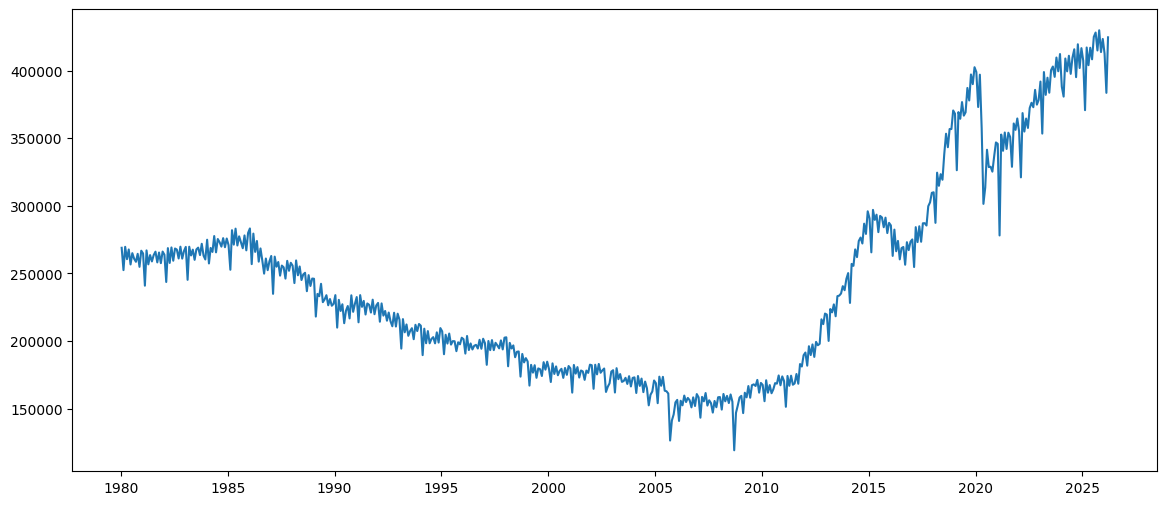

In [124]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(14, 6))
plt.plot(
    df["Date"], 
    df["Production"],
    label="Historical Production"
)
plt.plot(
    df["Date"],
    df["Forecast"],
    label="Forecast (2026-2031)"
)
plt.title("U.S Crude Oil Production Foreacast (Next 5 years)")
plt.xlabel("Year")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

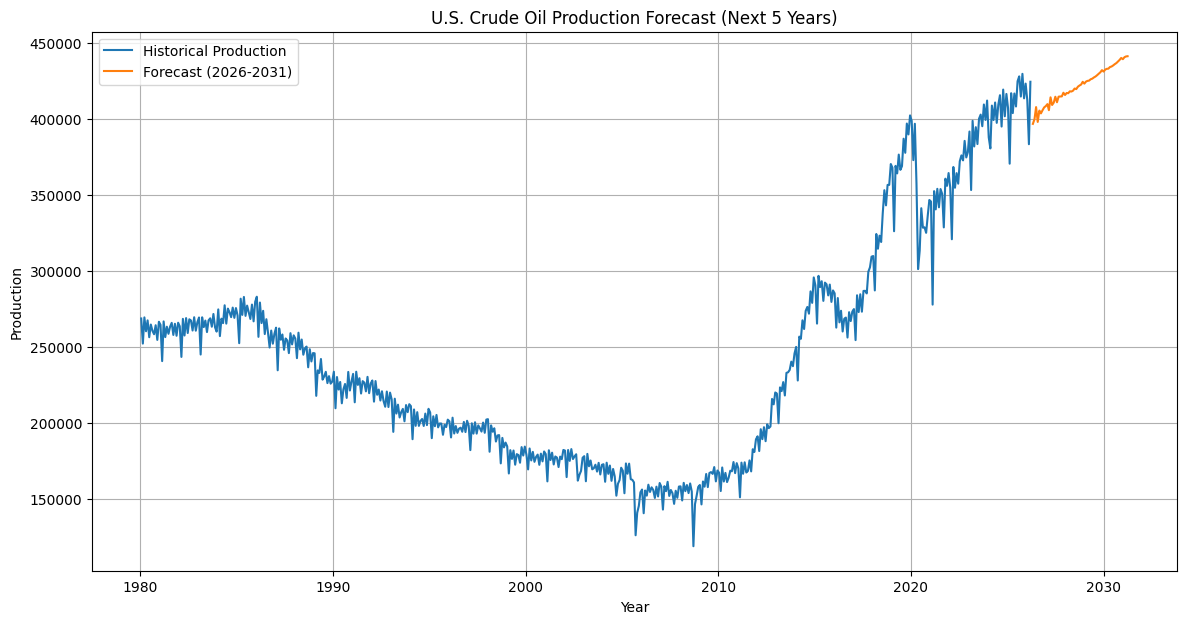

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(
    df["Date"],
    df["Production"],
    label="Historical Production"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    label="Forecast (2026-2031)"
)

plt.title(
    "U.S. Crude Oil Production Forecast (Next 5 Years)"
)

plt.xlabel("Year")
plt.ylabel("Production")

plt.legend()

plt.grid(True)

plt.show()

In [126]:
forecast_df.describe()

,Date,Forecast
count,60,60.000000
mean,2028-10-15 19:12:00,422060.482339
min,2026-05-01 00:00:00,396881.555680
25%,2027-07-24 06:00:00,414618.318573
50%,2028-10-16 12:00:00,422417.845572
75%,2030-01-08 18:00:00,432290.230597
max,2031-04-01 00:00:00,441358.213569
std,NaN,11938.126662
